# Classification in Latent Space Demo

**Are CelebA attributes linearly decodable from latent representations of the images** — either **diffusion inversion latents** (“noises”) or **encoder outputs**?

You choose `MODEL_NAME`, optionally **PCA** and **standardize** the vectors, then fit **one linear model per attribute** (40 binary labels) and report **test accuracy and ROC AUC** per attribute.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from utils import data_utils, normality_tests, train_classifier

/home/chent/UNE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data and split

Load precomputed **noises** for `MODEL_NAME` (same ordering as the CelebA train split) and build a **train/test index split**. Everything below uses these matrices; change `MODEL_NAME` once at the top to switch models.

In [6]:
# Configuration
MODEL_NAME = 'sd15'  # or sd15, lcmv7, vitL14, vitB16, dino, etc.

# Load latent encodings (noises)
noises = data_utils.load_noises(MODEL_NAME)[0]
ds = data_utils.get_ds('celeba', 'train')
Y = np.array(ds['attributes'])

print(f'Loaded {noises.shape[0]} samples, latent dim={noises.shape[1]}')

Loaded 162770 samples, latent dim=16384


## 2. Quick inversion sanity check

For **inversion** latents only, it helps to sanity-check that the code looks like a proper latent and **not** a skewed copy of the image embedding. In this section, we apply **random-projection normality tests** and, for Stable-Diffusion-style models, a quick **4-channel spatial view**.

**Why bother:** For **diffusion inversion**, this is a small extra signal that the stored vector behaves more like a **noise-shaped latent** than a residual of the original signal. This is not the main point of the notebook, and not a rigorous distributional proof.

In [3]:
# Raw latent matrix (same scale as stored; do not PCA/scale before this block)
NORM_PROJECTIONS = 5000   # increase for stabler estimates (slower)
NORM_SUBSET = 250
NORM_SEED = 42

rp = normality_tests.random_projection_normality_tests(
    noises,
    n_projections=NORM_PROJECTIONS,
    subset_size=NORM_SUBSET,
    ad_sig_level=5,
    random_state=NORM_SEED,
)
summ = normality_tests.summarize_random_projection_results(rp)

print(f"Model: {MODEL_NAME}  (latent dim={noises.shape[1]})")
print(f"  Anderson–Darling: mean stat={summ['ad_stat_mean']:.4f} ± {summ['ad_stat_std']:.4f}  |  pass rate={summ['ad_pass_rate_pct']:.1f}%")
print(f"  D'Agostino–Pearson: mean p={summ['dp_pval_mean']:.4f} ± {summ['dp_pval_std']:.4f}  |  pass rate={summ['dp_pass_rate_pct']:.1f}%")
print(f"  Shapiro–Wilk: mean p={summ['sw_pval_mean']:.4f} ± {summ['sw_pval_std']:.4f}  |  pass rate={summ['sw_pass_rate_pct']:.1f}%")

/home/chent/UNE/examples/../utils/normality_tests.py:10: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = anderson(data, dist='norm')


Model: sd15  (latent dim=16384)
  Anderson–Darling: mean stat=0.3811 ± 0.1859  |  pass rate=95.6%
  D'Agostino–Pearson: mean p=0.5088 ± 0.2907  |  pass rate=95.4%
  Shapiro–Wilk: mean p=0.5010 ± 0.2877  |  pass rate=95.5%


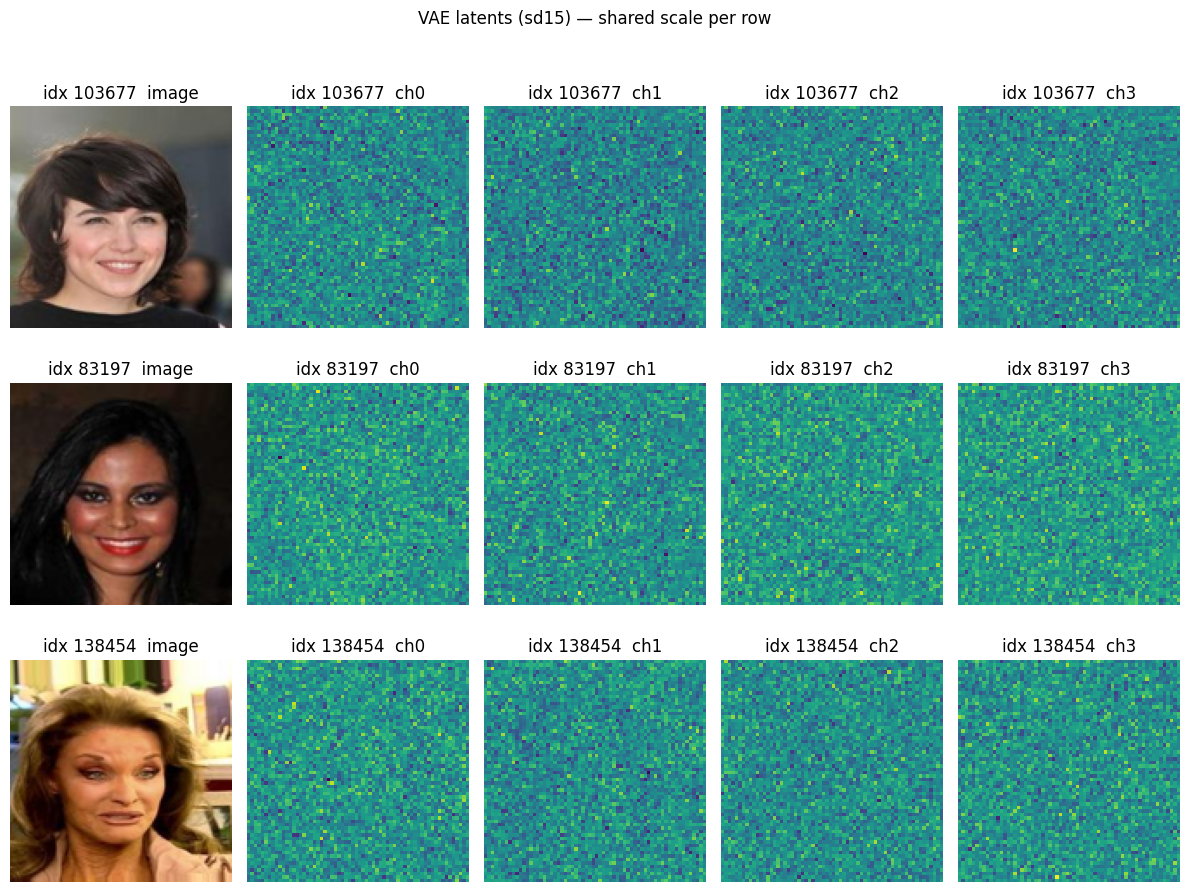

In [4]:
N_PREVIEW = 3
rng = np.random.default_rng(0)
preview_idx = rng.choice(len(noises), size=min(N_PREVIEW, len(noises)), replace=False)

def reshape_flat_latent_to_chw(vector):
    """
    Reshape a single flattened latent row to (C, H, W) when the size matches a known VAE layout.
    Returns None if unknown (caller should skip spatial plots).
    """
    d = vector.size
    c = 4
    h = int(np.sqrt(d/c)) # Assuming square latent
    w = int(d/c/h)
    if h * w * c != d:
        return None
    return vector.reshape(c, h, w)


def is_spatial_diffusion_latent_model(model_name):
    # Models whose CelebA latents are spatial diffusion VAE tensors stored flattened (for reshaping / plots)
    SPATIAL_DIFFUSION_MODELS = frozenset({
        'sd15', 'sd21', 'sdxl', 'lcmv7',
    })
    return model_name in SPATIAL_DIFFUSION_MODELS

if not is_spatial_diffusion_latent_model(MODEL_NAME):
    print(f"Skipping spatial latent plot: {MODEL_NAME} is treated as a non-spatial encoder representation.")
else:
    probe = reshape_flat_latent_to_chw(noises[preview_idx[0]])
    if probe is None:
        print(f"Unknown flattened layout for dim={noises.shape[1]} ({MODEL_NAME}); add a case in reshape_flat_latent_to_chw if needed.")
    else:
        fig, axes = plt.subplots(
            len(preview_idx), 5, figsize=(12, 3 * len(preview_idx)),
            squeeze=False,
        )
        for row, i in enumerate(preview_idx):
            im = axes[row, 0].imshow(ds[i]['image'].resize((128, 128)), aspect='equal')
            axes[row, 0].axis('off')
            axes[row, 0].set_title(f'idx {i}  image')
            
            chw = reshape_flat_latent_to_chw(noises[i])
            lo, hi = float(chw.min()), float(chw.max())
            for c in range(4):
                im = axes[row, c+1].imshow(chw[c], aspect='equal', vmin=lo, vmax=hi)
                axes[row, c+1].set_title(f'idx {i}  ch{c}')
                axes[row, c+1].axis('off')
            #fig.colorbar(im, ax=axes[row], shrink=1, label='latent value')
        plt.suptitle(f'VAE latents ({MODEL_NAME}) — shared scale per row', y=1.02)
        plt.tight_layout()
        plt.show()

## 3. Train linear classifiers

One **binary** linear model per attribute (`METHOD`: LDA, logistic regression, …). This is the core **linear decodability** experiment: can each label be predicted from the latent with a linear boundary?

In [ ]:
METHOD = 'lr'  # 'lda', 'lr', or 'sgd'
PCA_DIM = 500  # Reduce dimensionality for diffusion latents; use ~310 for encoders & 500 for SDs

results = train_classifier.train_classifier(
    noises, Y, MODEL_NAME,
    pca_dim=PCA_DIM,
    do_standard=True,
    method=METHOD,
    kwargs={'max_iter': 5000} if METHOD == 'lr' else {}
)

accs = results['test_accs']
aucs = results['test_aucs']
print(f'Mean accuracy: {accs.mean():.4f}')
print(f'Mean AUC: {aucs.mean():.4f}')

Applying PCA (dim = 500)
Explained variance ratio: 0.06743451244944833


100%|██████████| 40/40 [08:52<00:00, 13.31s/it]


Mean accuracy: 0.8707
Mean AUC: 0.8551


## 4. Visualize results

**Per-attribute** test accuracy and ROC AUC as bar plots—how strong linear decoding is for each attribute under the chosen `MODEL_NAME`.

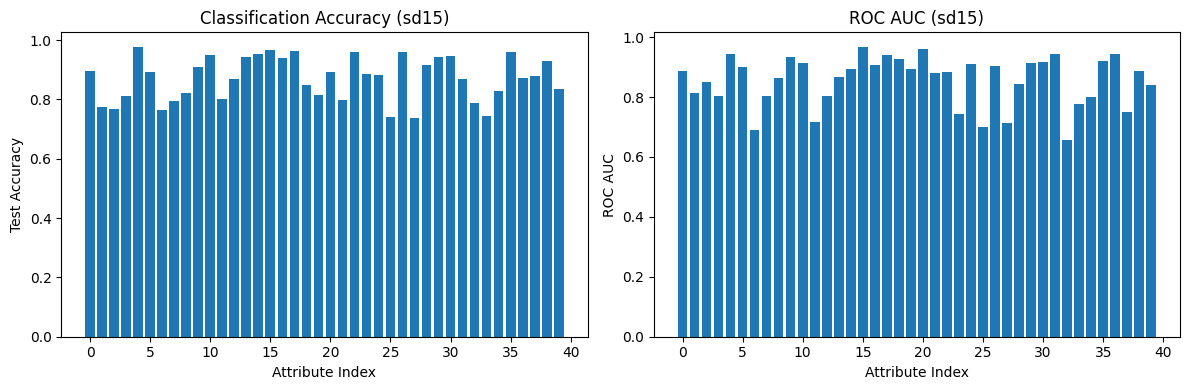

In [4]:
attr_names = data_utils.get_celeba_attribute_names()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(40), accs)
axes[0].set_xlabel('Attribute Index')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title(f'Classification Accuracy ({MODEL_NAME})')

axes[1].bar(range(40), aucs)
axes[1].set_xlabel('Attribute Index')
axes[1].set_ylabel('ROC AUC')
axes[1].set_title(f'ROC AUC ({MODEL_NAME})')

plt.tight_layout()
plt.show()

## 5. (Optional) Save weights

**Optional:** write `W_clf`, `b_clf`, PCA, and scaler to `results/` if another script needs the same directions (editing for example)—otherwise you can skip running this cell.

In [5]:
data_utils.save_results([results], results_dir="../results")
print('Results saved. Use W_clf[attr_idx] and b_clf[attr_idx] with edit_sample()')

Results saved. Use W_clf[attr_idx] and b_clf[attr_idx] with edit_sample()
